In [2]:
import pandas as pd

# Path is relative to the notebooks/ folder, so we go up one level (..)
df = pd.read_csv("../data/raw/tickets.csv")

print("Loaded successfully!")
print("Shape (rows, columns):", df.shape)

Loaded successfully!
Shape (rows, columns): (26872, 5)


In [3]:
print("Columns:", list(df.columns))
df.head()

Columns: ['flags', 'instruction', 'category', 'intent', 'response']


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


## Step 3: Check class distribution

This tells us how many tickets exist per category. If one category has way more
tickets than others, that's called "class imbalance" and it can bias the model.


In [4]:
category_counts = df["category"].value_counts()
print(category_counts)

category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


<Axes: title={'center': 'Tickets per Category'}, xlabel='category'>

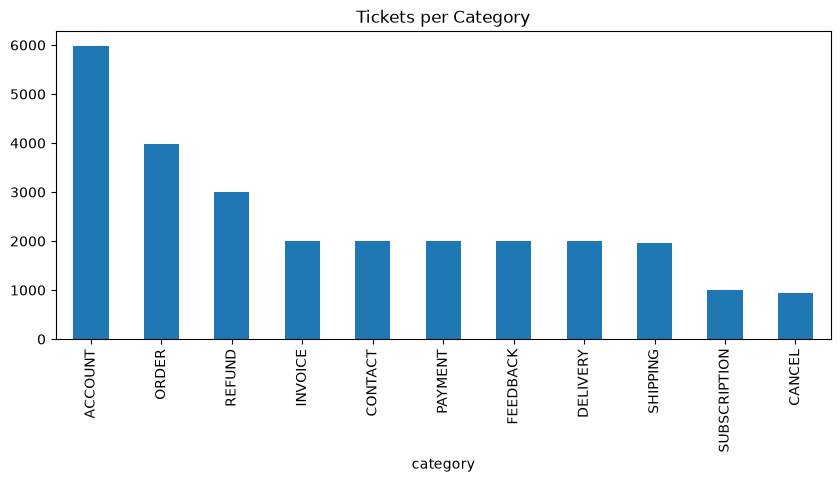

In [5]:
# Visualize it as a bar chart - easier to see imbalance visually
category_counts.plot(kind="bar", figsize=(10, 4), title="Tickets per Category")

**What to look for:** ACCOUNT has the most tickets (~5400), CANCEL has the fewest (~950).
This is a mild imbalance - not extreme, but worth knowing. This is why `train.py`
later uses `class_weight="balanced"` when training the model - it tells the model
to pay more attention to smaller categories so it doesn't ignore them.


## Step 4: Look at actual ticket text samples

Numbers and column names only tell you so much - let's actually READ a few tickets
to understand what the model will be learning from.


In [6]:
# Show 3 random tickets from a few different categories
for cat in ["REFUND", "PAYMENT", "ACCOUNT"]:
    print(f"--- {cat} examples ---")
    samples = df[df["category"] == cat]["instruction"].sample(3, random_state=1)
    for s in samples:
        print(" -", s)
    print()

--- REFUND examples ---
 - how can I get refunds?
 - i have to see ur reimbursement policy i need assistance
 - I have got to see my refund status, can you help me?

--- PAYMENT examples ---
 - help me check the accepted payment modalities
 - I do not know what I have to do to report payment issues
 - assistance to check your payment modalities

--- ACCOUNT examples ---
 - I don't know what I need to do to restore my PIN
 - i need assistance to create a platinum acfount for my fiance
 - I want to restore the key of my account



## Step 5: Check for missing or duplicate data

Before we move to preprocessing, let's confirm there's no missing text and
check how many exact duplicate tickets exist.


In [7]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate ticket texts:", df["instruction"].duplicated().sum())

Missing values per column:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Duplicate ticket texts: 2237
